<a href="https://colab.research.google.com/github/wtryab-re/data-preprocessing/blob/main/Financial_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports and Installations

In [322]:
#!/bin/bash
!kaggle datasets download atharvaarya25/financials

Dataset URL: https://www.kaggle.com/datasets/atharvaarya25/financials
License(s): DbCL-1.0
financials.zip: Skipping, found more recently modified local copy (use --force to force download)


In [323]:
!pip install -q numpy pandas seaborn matplotlib imbalanced-learn scikit-learn

In [324]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from zipfile import ZipFile

#Data Import and Unzip

In [325]:
ZipFile("financials.zip", "r").extractall()

#Dataset Load

In [326]:
og_df = pd.read_csv("Financials.csv")
og_df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [327]:
df = og_df.copy()

#Data Overview

In [328]:
df.shape

(700, 16)

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [330]:
df.describe()

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [331]:
df.columns

Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')

In [332]:
df.dtypes

,0
Segment,object
Country,object
Product,object
Discount Band,object
Units Sold,object
Manufacturing Price,object
Sale Price,object
Gross Sales,object
Discounts,object
Sales,object


#Data Quality Check

#String Inconsistencies

##Null Check

In [333]:
df.isna().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


##High Zero Check

In [334]:
#For later because have to fix the data first?

In [335]:
df[df == 0].sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


##String Inconsistencies

In [336]:
df.columns = [col.lower() for col in df.columns]
df.columns = [col.strip() for col in df.columns]
df.columns

Index(['segment', 'country', 'product', 'discount band', 'units sold',
       'manufacturing price', 'sale price', 'gross sales', 'discounts',
       'sales', 'cogs', 'profit', 'date', 'month number', 'month name',
       'year'],
      dtype='object')

In [337]:
string_columns = df.select_dtypes(exclude=np.number).columns
df[string_columns] = df[string_columns].apply(lambda x: x.str.lower())
df[string_columns] = df[string_columns].apply(lambda x: x.str.strip())
string_columns

Index(['segment', 'country', 'product', 'discount band', 'units sold',
       'manufacturing price', 'sale price', 'gross sales', 'discounts',
       'sales', 'cogs', 'profit', 'date', 'month name'],
      dtype='object')

In [338]:
df.head()

,segment,country,product,discount band,units sold,manufacturing price,sale price,gross sales,discounts,sales,cogs,profit,date,month number,month name,year
0,government,canada,carretera,none,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,january,2014
1,government,germany,carretera,none,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,january,2014
2,midmarket,france,carretera,none,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,june,2014
3,midmarket,germany,carretera,none,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,june,2014
4,midmarket,mexico,carretera,none,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,june,2014


In [339]:
fix_columns = ["units sold", "manufacturing price", "sale price", "gross sales", "sales", "cogs", "profit", "discounts" ]

In [340]:
for col in df.columns:
  print(col, df[col].unique())

segment ['government' 'midmarket' 'channel partners' 'enterprise' 'small business']
country ['canada' 'germany' 'france' 'mexico' 'united states of america']
product ['carretera' 'montana' 'paseo' 'velo' 'vtt' 'amarilla']
discount band ['none' 'low' 'medium' 'high']
units sold ['$1,618.50' '$1,321.00' '$2,178.00' '$888.00' '$2,470.00' '$1,513.00'
 '$921.00' '$2,518.00' '$1,899.00' '$1,545.00' '$2,665.50' '$958.00'
 '$2,146.00' '$345.00' '$615.00' '$292.00' '$974.00' '$1,006.00' '$367.00'
 '$883.00' '$549.00' '$788.00' '$2,472.00' '$1,143.00' '$1,725.00'
 '$912.00' '$2,152.00' '$1,817.00' '$1,493.00' '$1,804.00' '$2,161.00'
 '$2,821.00' '$2,001.00' '$2,838.00' '$1,527.00' '$2,151.00' '$2,750.00'
 '$1,953.00' '$4,219.50' '$1,686.00' '$2,141.00' '$3,945.00' '$2,296.00'
 '$1,030.00' '$639.00' '$1,326.00' '$1,858.00' '$1,210.00' '$2,529.00'
 '$1,445.00' '$330.00' '$2,671.00' '$766.00' '$494.00' '$1,397.00'
 '$2,155.00' '$2,214.00' '$2,301.00' '$1,375.50' '$1,830.00' '$2,498.00'
 '$663.00' '

In [341]:
df[fix_columns] = df[fix_columns].astype(str).replace({",": "", r"\$":""}, regex=True)
# Convert parenthesized numbers to negative floats and strip whitespace
for col in fix_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].apply(lambda x: '-' + x[1:-1] if x.startswith('(') and x.endswith(')') else x)
df[fix_columns] = df[fix_columns].replace({r"\$-":np.nan, r"-":np.nan}, regex=True)

In [342]:
for col in df.columns:
  print(col, df[col].unique())

segment ['government' 'midmarket' 'channel partners' 'enterprise' 'small business']
country ['canada' 'germany' 'france' 'mexico' 'united states of america']
product ['carretera' 'montana' 'paseo' 'velo' 'vtt' 'amarilla']
discount band ['none' 'low' 'medium' 'high']
units sold ['1618.50' '1321.00' '2178.00' '888.00' '2470.00' '1513.00' '921.00'
 '2518.00' '1899.00' '1545.00' '2665.50' '958.00' '2146.00' '345.00'
 '615.00' '292.00' '974.00' '1006.00' '367.00' '883.00' '549.00' '788.00'
 '2472.00' '1143.00' '1725.00' '912.00' '2152.00' '1817.00' '1493.00'
 '1804.00' '2161.00' '2821.00' '2001.00' '2838.00' '1527.00' '2151.00'
 '2750.00' '1953.00' '4219.50' '1686.00' '2141.00' '3945.00' '2296.00'
 '1030.00' '639.00' '1326.00' '1858.00' '1210.00' '2529.00' '1445.00'
 '330.00' '2671.00' '766.00' '494.00' '1397.00' '2155.00' '2214.00'
 '2301.00' '1375.50' '1830.00' '2498.00' '663.00' '1514.00' '4492.50'
 '727.00' '787.00' '1823.00' '747.00' '2905.00' '3864.00' '362.00'
 '923.00' '2092.00' '26

##Duplicated

In [343]:
df.duplicated().sum()

np.int64(0)

##Constant, quasi-constant, id-like

In [344]:
constant_cols =[]
quasi_constant_cols = []
id_like = []

for col in df.columns:
  #constant
  if df[col].nunique() == 1:
    constant_cols.append(col)
  elif df[col].value_counts(normalize=True).max() > 0.90:
    #quasi_constant
    quasi_constant_cols.append(col)
  elif df[col].nunique()/df.shape[0] > 0.95:
    #id-like
    print(col,df[col].nunique())
    id_like.append(col)

constant_cols, quasi_constant_cols, id_like

([], [], [])

In [345]:
for col in df.columns:
  print(col, df[col].nunique())

segment 5
country 5
product 6
discount band 4
units sold 510
manufacturing price 6
sale price 7
gross sales 550
discounts 514
sales 559
cogs 545
profit 505
date 16
month number 12
month name 12
year 2


#Changing Data Types

In [346]:
df.sample(1)

,segment,country,product,discount band,units sold,manufacturing price,sale price,gross sales,discounts,sales,cogs,profit,date,month number,month name,year
513,government,mexico,paseo,high,1122.00,10.00,20.00,22440.00,2468.40,19971.60,11220.00,8751.60,01/03/2014,3,march,2014


In [347]:
change_columns = ["units sold", "manufacturing price", "sale price", "gross sales", "sales", "cogs", "profit", "discounts", "year"]

In [348]:
df[change_columns]=df[change_columns].astype(float)
df.dtypes

,0
segment,object
country,object
product,object
discount band,object
units sold,float64
manufacturing price,float64
sale price,float64
gross sales,float64
discounts,float64
sales,float64


In [349]:
df["date"] = df["date"].astype("datetime64[ns]")
df.dtypes

,0
segment,object
country,object
product,object
discount band,object
units sold,float64
manufacturing price,float64
sale price,float64
gross sales,float64
discounts,float64
sales,float64


#oops dropping month name because they are redundant

In [350]:
df.drop("month name", inplace=True, axis=1)

#Train Test Split

In [351]:
df["sales"]

,sales
0,32370.00
1,26420.00
2,32670.00
3,13320.00
4,37050.00
...,...
695,631125.00
696,139230.00
697,8139.60
698,4301.85


In [352]:
X= df.drop(["sales"], inplace=False, axis=1)
y = df["sales"]
X,y

(              segment                   country  ... month number    year
 0          government                    canada  ...            1  2014.0
 1          government                   germany  ...            1  2014.0
 2           midmarket                    france  ...            6  2014.0
 3           midmarket                   germany  ...            6  2014.0
 4           midmarket                    mexico  ...            6  2014.0
 ..                ...                       ...  ...          ...     ...
 695    small business                    france  ...            3  2014.0
 696    small business                    mexico  ...           10  2014.0
 697        government                    mexico  ...            2  2014.0
 698        government                    canada  ...            4  2014.0
 699  channel partners  united states of america  ...            5  2014.0
 
 [700 rows x 14 columns],
 0       32370.00
 1       26420.00
 2       32670.00
 3       13320.00


In [353]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((560, 14), (140, 14), (560,), (140,))

#Columns Identification

In [354]:
df.head()

,segment,country,product,discount band,units sold,manufacturing price,sale price,gross sales,discounts,sales,cogs,profit,date,month number,year
0,government,canada,carretera,none,1618.5,3.0,20.0,32370.0,NaN,32370.0,16185.0,16185.0,2014-01-01,1,2014.0
1,government,germany,carretera,none,1321.0,3.0,20.0,26420.0,NaN,26420.0,13210.0,13210.0,2014-01-01,1,2014.0
2,midmarket,france,carretera,none,2178.0,3.0,15.0,32670.0,NaN,32670.0,21780.0,10890.0,2014-01-06,6,2014.0
3,midmarket,germany,carretera,none,888.0,3.0,15.0,13320.0,NaN,13320.0,8880.0,4440.0,2014-01-06,6,2014.0
4,midmarket,mexico,carretera,none,2470.0,3.0,15.0,37050.0,NaN,37050.0,24700.0,12350.0,2014-01-06,6,2014.0


In [355]:
#in this case it is categorical
num_cols = ["units sold", "manufacturing price", "sale price", "gross sales", "discounts", "cogs", "profit"]
cat_cols = list(filter(lambda x: x not in num_cols, X_train.columns))
num_cols,cat_cols

(['units sold',
  'manufacturing price',
  'sale price',
  'gross sales',
  'discounts',
  'cogs',
  'profit'],
 ['segment',
  'country',
  'product',
  'discount band',
  'date',
  'month number',
  'year'])

In [356]:
##date is numerical when calculating distance
##date is categorical if want to calculate trend

#Handle Missing Values

In [357]:
df.isna().sum()

,0
segment,0
country,0
product,0
discount band,0
units sold,0
manufacturing price,0
sale price,0
gross sales,0
discounts,53
sales,0


In [358]:
imputer = SimpleImputer(strategy="median")
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

In [359]:
imputer=SimpleImputer(strategy="most_frequent")
X_train[cat_cols] = imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = imputer.transform(X_test[cat_cols])

In [360]:
X_train.isna().sum()

,0
segment,0
country,0
product,0
discount band,0
units sold,0
manufacturing price,0
sale price,0
gross sales,0
discounts,0
cogs,0


#Outlier Detection

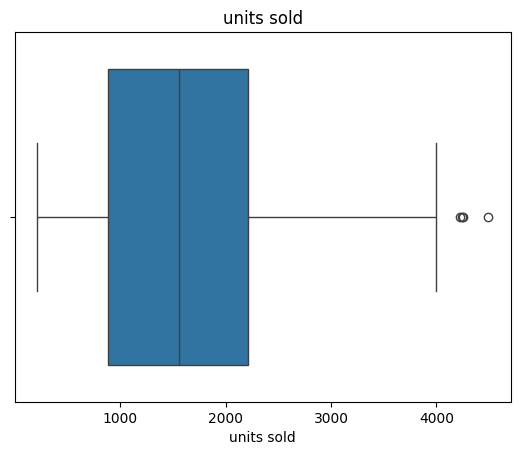

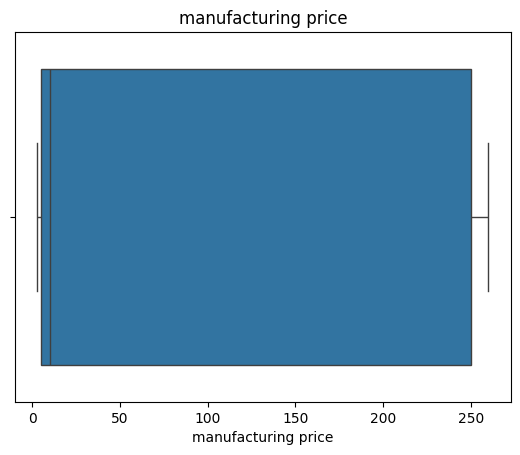

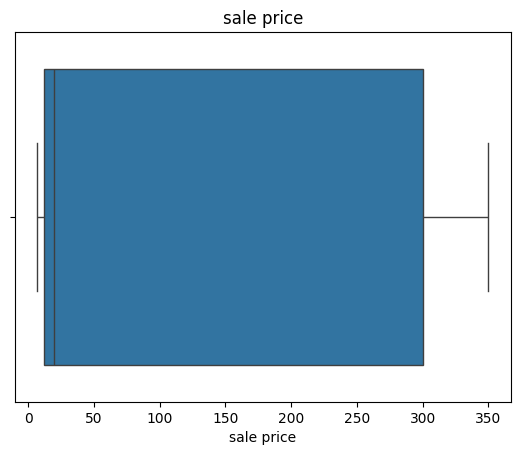

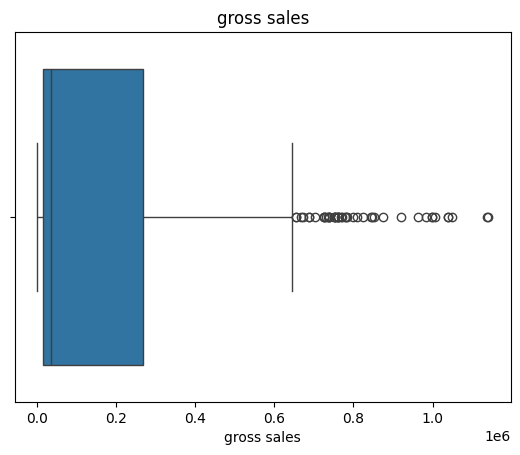

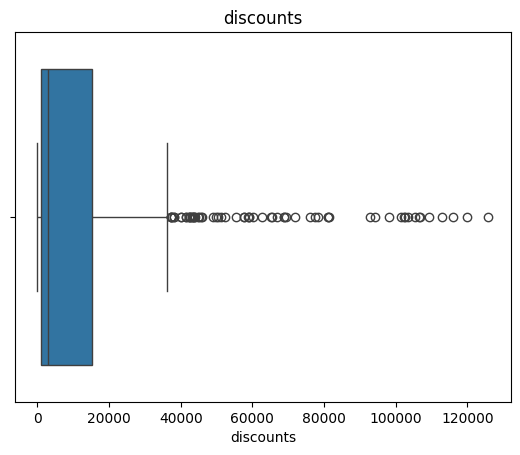

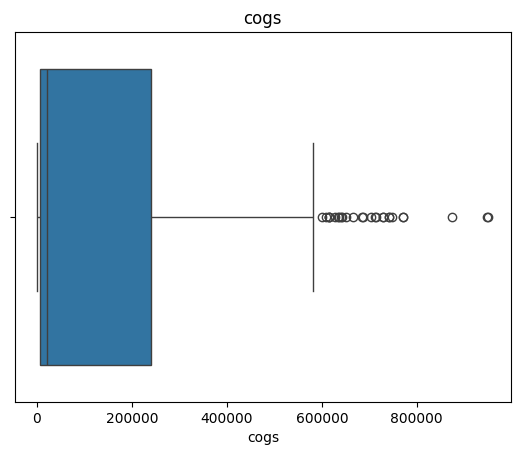

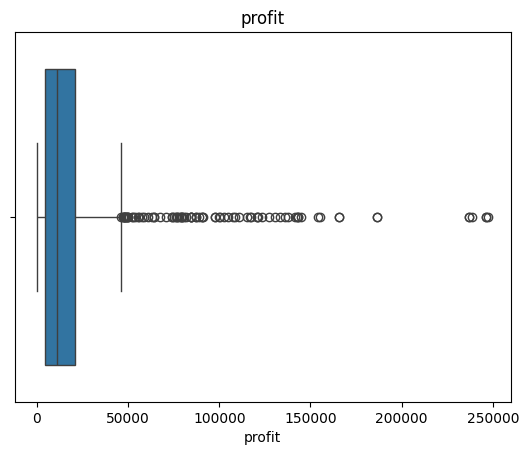

In [361]:
for col in num_cols:
  sns.boxplot(x=X_train[col])
  plt.title(col)
  plt.show()
  print()

In [362]:
def boundary_finder(df, col):
  Q3 = df[col].quantile(0.75)
  Q1 = df[col].quantile(0.25)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR

  return lower_bound, upper_bound

In [363]:
def iqr_method():
  train_boundaries={}
  for col in num_cols:
    lower_bound, upper_bound = boundary_finder(X_train, col)

    X_train.loc[X_train[col]<lower_bound, col] = lower_bound
    X_train.loc[X_train[col]>upper_bound, col] = upper_bound

    X_test.loc[X_test[col]<lower_bound, col] = lower_bound
    X_test.loc[X_test[col]>upper_bound, col] = upper_bound

    train_boundaries[col] = [lower_bound, upper_bound]

  return train_boundaries

In [364]:
train_boundaries = iqr_method()
train_boundaries

{'units sold': [np.float64(-1104.625), np.float64(4208.375)],
 'manufacturing price': [np.float64(-362.5), np.float64(617.5)],
 'sale price': [np.float64(-420.0), np.float64(732.0)],
 'gross sales': [np.float64(-360401.25), np.float64(645790.75)],
 'discounts': [np.float64(-20038.125000000004), np.float64(36417.675)],
 'cogs': [np.float64(-342367.5), np.float64(589552.5)],
 'profit': [np.float64(-20453.4375), np.float64(45920.662500000006)]}

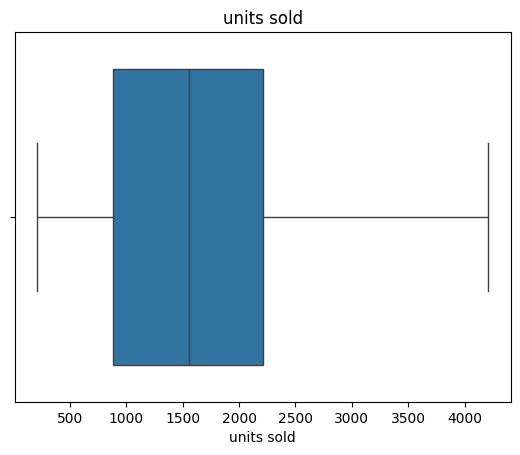

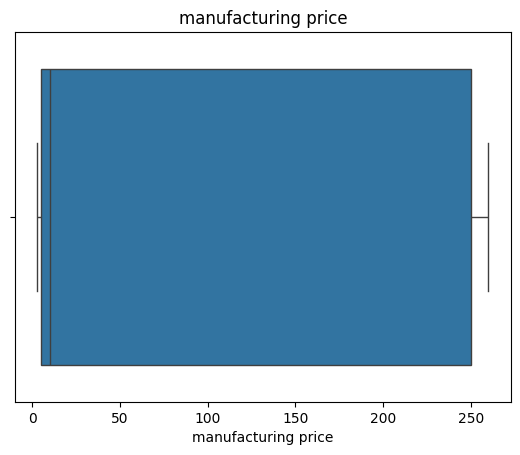

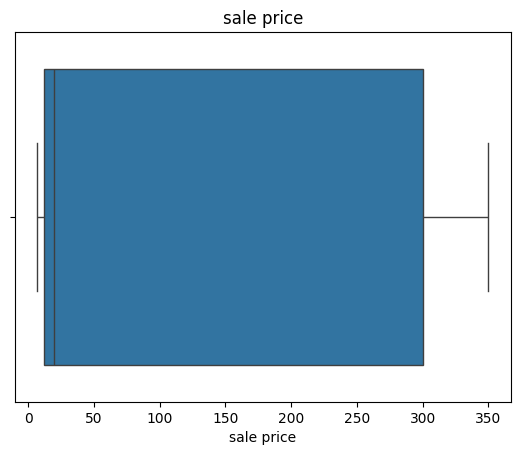

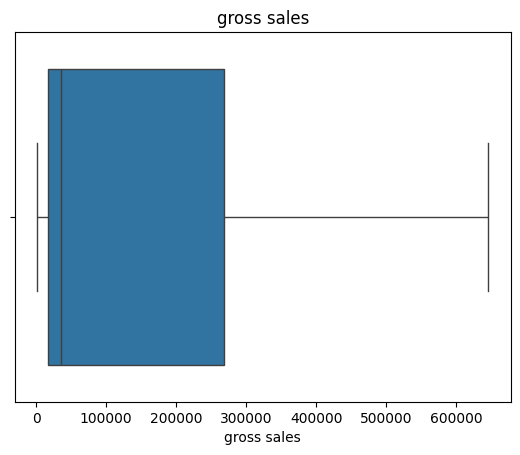

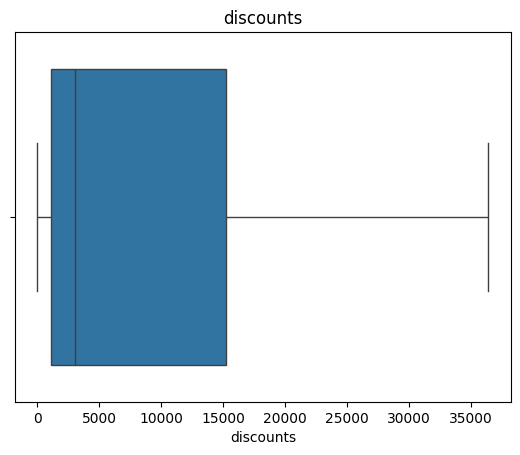

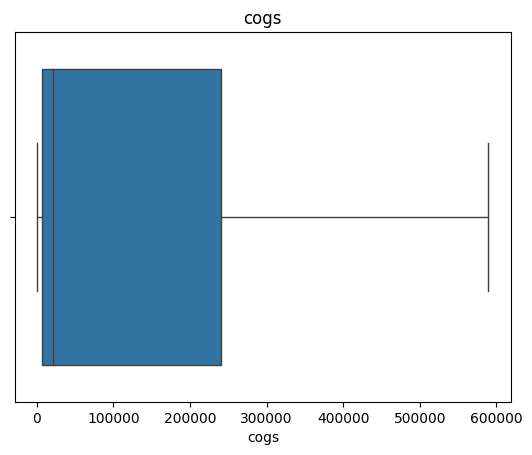

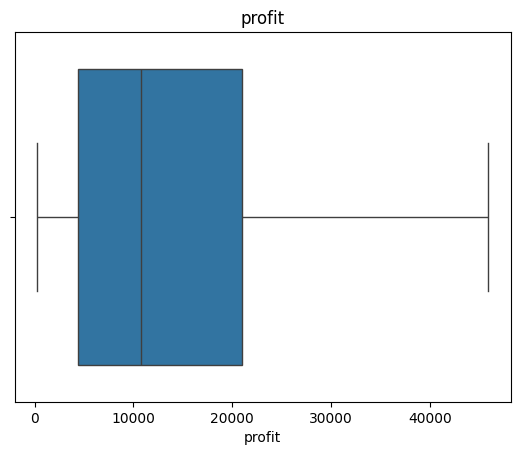

In [365]:
for col in num_cols:
  sns.boxplot(x=X_train[col])
  plt.title(col)
  plt.show()
  print()

#Encoding

In [366]:
df[cat_cols].sample()

,segment,country,product,discount band,date,month number,year
671,midmarket,canada,paseo,high,2014-01-04,4,2014.0


In [367]:
for col in cat_cols:
  print(col, X_train[col].unique())

segment ['government' 'small business' 'midmarket' 'channel partners' 'enterprise']
country ['france' 'united states of america' 'mexico' 'canada' 'germany']
product ['paseo' 'amarilla' 'montana' 'vtt' 'velo' 'carretera']
discount band ['low' 'none' 'medium' 'high']
date <DatetimeArray>
['2014-01-12 00:00:00', '2014-01-10 00:00:00', '2014-01-07 00:00:00',
 '2013-01-12 00:00:00', '2013-01-10 00:00:00', '2014-01-06 00:00:00',
 '2013-01-09 00:00:00', '2014-01-04 00:00:00', '2013-01-11 00:00:00',
 '2014-01-09 00:00:00', '2014-01-08 00:00:00', '2014-01-03 00:00:00',
 '2014-01-11 00:00:00', '2014-01-02 00:00:00', '2014-01-01 00:00:00',
 '2014-01-05 00:00:00']
Length: 16, dtype: datetime64[ns]
month number [12 10 7 6 9 4 11 8 3 2 1 5]
year [2014.0 2013.0]


segment - ohe
country - ohe
product - ohe
discount band - label
date - ohe
month - label
year - same

#Encoding

In [368]:
le = LabelEncoder()

In [369]:
X_train["discount band"] = le.fit_transform(X_train["discount band"])
X_test["discount band"] = le.transform(X_test["discount band"])

In [370]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

In [376]:
xt_encoded =ohe.fit_transform(X_train[["segment", "country", "product"]])
xtt= ohe.transform(X_test[["segment", "country", "product"]])

In [375]:
ohe_col_names = ohe.get_feature_names_out()
ohe_col_names

array(['segment_enterprise', 'segment_government', 'segment_midmarket',
       'segment_small business', 'country_france', 'country_germany',
       'country_mexico', 'country_united states of america',
       'product_carretera', 'product_montana', 'product_paseo',
       'product_velo', 'product_vtt'], dtype=object)

In [384]:
bestie = pd.DataFrame(xt_encoded,columns=ohe_col_names, index=X_train.index)
bestie2 = pd.DataFrame(xtt,columns=ohe_col_names, index=X_test.index)

In [385]:
X_train_enc = pd.concat([X_train.drop(["segment", "country", "product"], axis=1), bestie], axis=1)
X_test_enc = pd.concat([X_test.drop(["segment", "country", "product"], axis=1), bestie2], axis=1)

In [386]:
X_train_enc.head()

,discount band,units sold,manufacturing price,sale price,gross sales,discounts,cogs,profit,date,month number,year,segment_enterprise,segment_government,segment_midmarket,segment_small business,country_france,country_germany,country_mexico,country_united states of america,product_carretera,product_montana,product_paseo,product_velo,product_vtt
82,1,2155.0,10.0,350.0,645790.75,7542.500,560300.0,45920.6625,2014-01-12,12,2014.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
51,3,1143.0,260.0,7.0,8001.00,3088.800,5715.0,2286.0000,2014-01-10,10,2014.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
220,2,1683.0,260.0,7.0,11781.00,589.050,8415.0,2776.9500,2014-01-07,7,2014.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
669,0,546.0,5.0,300.0,163800.00,24570.000,136500.0,2730.0000,2014-01-10,10,2014.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
545,0,1186.0,5.0,300.0,355800.00,36417.675,296500.0,16604.0000,2013-01-12,12,2013.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#Standardization

In [388]:
scaler = StandardScaler()

In [389]:
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols])

In [390]:
df_train = pd.concat([X_train_enc, y_train], axis=1)
df_test = pd.concat([X_test_enc, y_test], axis=1)

In [391]:
df_train.head()

,discount band,units sold,manufacturing price,sale price,gross sales,discounts,cogs,profit,date,month number,year,segment_enterprise,segment_government,segment_midmarket,segment_small business,country_france,country_germany,country_mexico,country_united states of america,product_carretera,product_montana,product_paseo,product_velo,product_vtt,sales
82,1,0.629479,-0.784383,1.740293,2.286572,-0.175848,2.306263,1.922427,2014-01-12,12,2014.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,746707.50
51,3,-0.534142,1.514609,-0.791483,-0.731726,-0.527196,-0.701819,-0.917844,2014-01-10,10,2014.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8001.00
220,2,0.086762,1.514609,-0.791483,-0.713838,-0.724399,-0.687174,-0.885887,2014-01-07,7,2014.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,11191.95
669,0,-1.220586,-0.830363,1.371229,0.005582,1.167436,0.007562,-0.888943,2014-01-10,10,2014.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,139230.00
545,0,-0.484700,-0.830363,1.371229,0.914210,2.102088,0.875406,0.014144,2013-01-12,12,2013.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,313104.00


In [392]:
df_train.to_csv("train.csv", index=False)
df_test.to_csv("test.csv", index=False)